<a href="https://colab.research.google.com/github/hannah-u-dennis/EBUS-Climatechange-upwelling-primaryproductivity/blob/main/tutorials/W1D5_IntroductiontoClimateModeling/student/W1D5_Tutorial2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/neuromatch/climate-course-content/blob/main/tutorials/W1D5_IntroductiontoClimateModeling/student/W1D5_Tutorial2.ipynb) &nbsp; <a href="https://kaggle.com/kernels/welcome?src=https://raw.githubusercontent.com/neuromatch/climate-course-content/main/tutorials/W1D5_IntroductiontoClimateModeling/student/W1D5_Tutorial2.ipynb" target="_parent"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open in Kaggle"/></a>

# Tutorial 2: Energy Balance


**Week 1, Day 5, Introduction to Climate Modeling**

**Content creators:** Jenna Pearson and Brian E. J. Rose

**Content reviewers:** Mujeeb Abdulfatai, Nkongho Ayuketang Arreyndip, Jeffrey N. A. Aryee, Dionessa Biton, Younkap Nina Duplex, Will Gregory, Paul Heubel, Zahra Khodakaramimaghsoud, Peter Ohue, Abel Shibu, Derick Temfack, Yunlong Xu, Peizhen Yang, Chi Zhang, Ohad Zivan

**Content editors:** Brodie Pearson, Abigail Bodner, Ohad Zivan, Chi Zhang

**Production editors:** Wesley Banfield, Jenna Pearson, Konstantine Tsafatinos, Chi Zhang, Ohad Zivan

**Our 2024 Sponsors:** CMIP, NFDI4Earth


# Tutorial Objectives

*Estimated timing of tutorial:* 30 minutes

In this tutorial, you will learn about the components that define energy balance, including insolation and albedo.

By the end of this tutorial you will be able to:

- Calculate the albedo of Earth based on observations.
- Define and find the equilibrium temperature under the assumption of energy balance.
- Understand the relationship between transmissivity and equilibrium temperature.

*This tutorial is based on content from [The Climate Laboratory](https://brian-rose.github.io/ClimateLaboratoryBook/) by Brian E. J. Rose.*

# Setup

In [1]:
# imports
import numpy as np  # used for algebra and array operations
import matplotlib.pyplot as plt  # used for plotting

In [2]:
# @title Install and import feedback gadget

!pip3 install vibecheck datatops --quiet

from vibecheck import DatatopsContentReviewContainer
def content_review(notebook_section: str):
    return DatatopsContentReviewContainer(
        "",  # No text prompt
        notebook_section,
        {
            "url": "https://pmyvdlilci.execute-api.us-east-1.amazonaws.com/klab",
            "name": "comptools_4clim",
            "user_key": "l5jpxuee",
        },
    ).render()


feedback_prefix = "W1D5_T2"

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 50.5 MB/s eta 0:00:00


In [3]:
# @title Figure settings
import ipywidgets as widgets  # interactive display

%config InlineBackend.figure_format = 'retina'
plt.style.use(
    "https://raw.githubusercontent.com/neuromatch/climate-course-content/main/cma.mplstyle"
)

In [4]:
# @title Video 1: Energy Balance

from ipywidgets import widgets
from IPython.display import YouTubeVideo
from IPython.display import IFrame
from IPython.display import display


class PlayVideo(IFrame):
  def __init__(self, id, source, page=1, width=400, height=300, **kwargs):
    self.id = id
    if source == 'Bilibili':
      src = f'https://player.bilibili.com/player.html?bvid={id}&page={page}'
    elif source == 'Osf':
      src = f'https://mfr.ca-1.osf.io/render?url=https://osf.io/download/{id}/?direct%26mode=render'
    super(PlayVideo, self).__init__(src, width, height, **kwargs)


def display_videos(video_ids, W=400, H=300, fs=1):
  tab_contents = []
  for i, video_id in enumerate(video_ids):
    out = widgets.Output()
    with out:
      if video_ids[i][0] == 'Youtube':
        video = YouTubeVideo(id=video_ids[i][1], width=W,
                             height=H, fs=fs, rel=0)
        print(f'Video available at https://youtube.com/watch?v={video.id}')
      else:
        video = PlayVideo(id=video_ids[i][1], source=video_ids[i][0], width=W,
                          height=H, fs=fs, autoplay=False)
        if video_ids[i][0] == 'Bilibili':
          print(f'Video available at https://www.bilibili.com/video/{video.id}')
        elif video_ids[i][0] == 'Osf':
          print(f'Video available at https://osf.io/{video.id}')
      display(video)
    tab_contents.append(out)
  return tab_contents


video_ids = [('Youtube', 'MOo5Xa-Nfzc'), ('Bilibili', 'BV1oV4y127uo')]
tab_contents = display_videos(video_ids, W=730, H=410)
tabs = widgets.Tab()
tabs.children = tab_contents
for i in range(len(tab_contents)):
  tabs.set_title(i, video_ids[i][0])
display(tabs)

In [5]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Energy_Balance_Video")

In [6]:
# @markdown
from ipywidgets import widgets
from IPython.display import IFrame

link_id = "ce6mx"

print(f"If you want to download the slides: https://osf.io/download/{link_id}/")
IFrame(src=f"https://mfr.ca-1.osf.io/render?url=https://osf.io/{link_id}/?direct%26mode=render%26action=download%26mode=render", width=854, height=480)

If you want to download the slides: https://osf.io/download/ce6mx/


In [7]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Energy_Balance_Slides")

# Section 1: A Radiating Sun

## Section 1.1: Incoming Solar Radiation (Insolation) and Albedo ($\alpha$)

Just as Earth emits radiation, so does the sun. Radiation from the sun is referred to as *solar* or **[shortwave radiation](https://glossarytest.ametsoc.net/wiki/Shortwave_radiation)**. We will denote the incoming solar radiation, or **[insolation](https://glossary.ametsoc.org/wiki/Insolation)**, as $Q$.

From the 'All Sky' Energy budget shown below, the insolation is observed to be $Q = 340 \text{ W m}^{-2}$.

_Note that 'All Sky' refers to fluxes that **include the effects of clouds**. Compare the 'All Sky' figure to the 'Clear Sky' figure below, to see how the fluxes differ when measured only over regions that are cloud-free._

Some of this radiation is reflected back to space (for example off of ice and snow or clouds). We will denote the reflected flux back to space as $F_{\text{ref}}$.

From the 'All Sky' energy budget below, this reflected flux is $F_{\text{ref}} = 100 \text{ W m}^{-2}$.

![Global Mean Energy Budget](https://www.ipcc.ch/report/ar6/wg1/downloads/figures/IPCC_AR6_WGI_Figure_7_2.png)
Figure 7.2 | Schematic representation of the global mean energy budget of the Earth (upper panel), and its equivalent without considerations of cloud effects (lower panel). Numbers indicate best estimates for the magnitudes of the globally averaged energy balance components in $\text{ W m}^{-2}$ together with their uncertainty ranges in parentheses (5–95% confidence range), representing climate conditions at the beginning of the 21st century. Note that the cloud-free energy budget shown in the lower panel is not the one that Earth would achieve in equilibrium when no clouds could form. It rather represents the global mean fluxes as determined solely by removing the clouds but otherwise retaining the entire atmospheric structure. This enables the quantification of the effects of clouds on the Earth energy budget and corresponds to the way clear-sky fluxes are calculated in climate models. Thus, the cloud-free energy budget is not closed and therefore the sensible and latent heat fluxes are not quantified in the lower panel. Figure adapted from Wild et al. (2015, 2019). (Credit: [IPCC AR6 Report](https://www.ipcc.ch/report/ar6/wg1/downloads/figures/IPCC_AR6_WGI_Figure_7_2.png))

The _fraction_ of reflected radiation relative to the insolation is called the **[planetary albedo](https://glossarytest.ametsoc.net/wiki/Planetary_albedo)** or just **albedo (**$\mathbf{\alpha}$**)**

\begin{align}
\alpha = \frac{F_{\text{ref}}}{Q}
\end{align}

Albedo is a unitless number between 0 and 1. We can use this formula to find the albedo of Earth.

In [8]:
# define the observed insolation based on observations from the IPCC AR6 Figure 7.2
Q = 340  # W m^-2

# define the observed reflected radiation based on observations from the IPCC AR6 Figure 7.2
F_ref = 100  # W m^-2

# plug into equation
alpha = F_ref / Q  # unitless number between 0 and 1

# display answer
print("Albedo: ", alpha)

Albedo:  0.29411764705882354


### Questions 1.1: Climate Connection

1. Keeping insolation ($Q$) constant, what does a low albedo imply? What about a high albedo?
2. There are two components to albedo, the reflected radiation in the numerator and the insolation in the denomenator. Do you think one or both of these have changed over Earth's history?


[*Click for solution*](https://github.com/neuromatch/climate-course-content/tree/main/tutorials/W1D5_IntroductiontoClimateModeling/solutions/W1D5_Tutorial2_Solution_daefe4d6.py)



In [9]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Questions_1_1")

## Section 1.2: Absorbed Shortwave Radiation (ASR)

The **absorbed shortwave radiation (ASR)** is the amount of insolation that is _not_ reflected, and actually makes it to Earth's surface. Thus,

\begin{align}
ASR = Q-F_{\text{ref}} = (1-\alpha)Q
\end{align}

From observations, we can estimate the absorbed shortwave radiation.

In [10]:
# plug into equation
ASR = (1 - alpha) * Q

# display answer
print("Absorbed Shortwave Radiation: ", ASR, " W m^-2")

Absorbed Shortwave Radiation:  239.99999999999997  W m^-2


### Questions 1.2: Climate Connection

1. Compare the value of ASR to the observed OLR of $239 \text{ W m}^{-2}$. Is it more or less? What do you think this means?
2. Does this model take into account any effects of gases in that atmosphere on the solar radiation that makes it to Earth's surface? Are there any greenhouse gases you think are important and should be included in more complex models?

[*Click for solution*](https://github.com/neuromatch/climate-course-content/tree/main/tutorials/W1D5_IntroductiontoClimateModeling/solutions/W1D5_Tutorial2_Solution_826838b2.py)



In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Questions_1_2")

# Section 2: Energy Balance

## Section 2.1: Equilibrium Temperature

Energy Balance is achieved when radiation absorbed by Earth's surface (ASR) is equal to longwave radiation going out to space (OLR). That is

\begin{align}
ASR = OLR
\end{align}

By substituting into the equations from previous sections, we can find the surface temperature of Earth needed to maintain this balance. This is called the **equilibrium temperature (** $\mathbf{T_{\text{eq}}}$ **)**.

Recall $OLR = \tau\sigma T^4$ and $ASR = (1-\alpha)Q$. The **equilibrium temperature** is the temperature the system would have if the energy balance was perfectly reached. Assuming energy balance, we will call the emission temperature denoted previously the equilibrium temperature ($T_{\text{eq}}$) instead. Thus,

\begin{align}
(1-\alpha)Q = ASR = OLR = \tau\sigma T_{\text{eq}}^4
\end{align}

Solving for $T_{\text{eq}}$ we find

\begin{align}
T_{\text{eq}} = \sqrt[4]{\frac{(1-\alpha)Q}{\tau\sigma}}
\end{align}

Let's calculate what this should be for Earth using observations:


In [11]:
# define the Stefan-Boltzmann Constant, noting we are using 'e' for scientific notation
sigma = 5.67e-8  # W m^-2 K^-4

# define transmissivity (calculated previously from observations in tutorial 1)
tau = 0.6127  # unitless number between 0 and 1

# plug into equation
T_eq = (((1 - alpha) * Q) / (tau * sigma)) ** (1 / 4)

# display answer
print("Equilibrium Temperature: ", T_eq, "K or", T_eq - 273, "°C")

Equilibrium Temperature:  288.300287595812 K or 15.300287595811994 °C


# Section 3: Climate Change Scenario

## Section 3.1: Increasing Greenhouse Gas Concentrations

Assume due to the increasing presence of greenhouse gases in the the atmosphere, that $\tau$ decreases to $0.57$.

We can then use our climate model and python to find the new equilibrium temperature.


In [12]:
# define transmissivity (assupmtion in this case)
tau_2 = 0.57  # unitless number between 0 and 1

# plug into equation
T_eq_2 = (((1 - alpha) * Q) / (tau_2 * sigma)) ** (1 / 4)

# display answer
print("New Equilibrium Temperature: ", T_eq_2, "K or", T_eq_2 - 273, "°C")

New Equilibrium Temperature:  293.5542225759401 K or 20.554222575940116 °C


### Questions 3.1: Climate Connection

1.  Does a reduction in the transmissivity, $\tau$, imply a decrease or increase in OLR?
2.  How does the new equilibrium temperature compare to that calculated previously? Why do you think this is?


[*Click for solution*](https://github.com/neuromatch/climate-course-content/tree/main/tutorials/W1D5_IntroductiontoClimateModeling/solutions/W1D5_Tutorial2_Solution_79b144ab.py)



In [13]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Questions_3_1")

### Coding Exercises 3.1

1. Plot the equilibrium temperature as a function of $\tau$, for $\tau$ ranging from zero to one.


/tmp/ipykernel_2538/3576650594.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  return (((1 - alpha) * Q) / (tau * sigma)) ** (1 / 4)


Text(0, 0.5, 'Equilibrium Temperature')

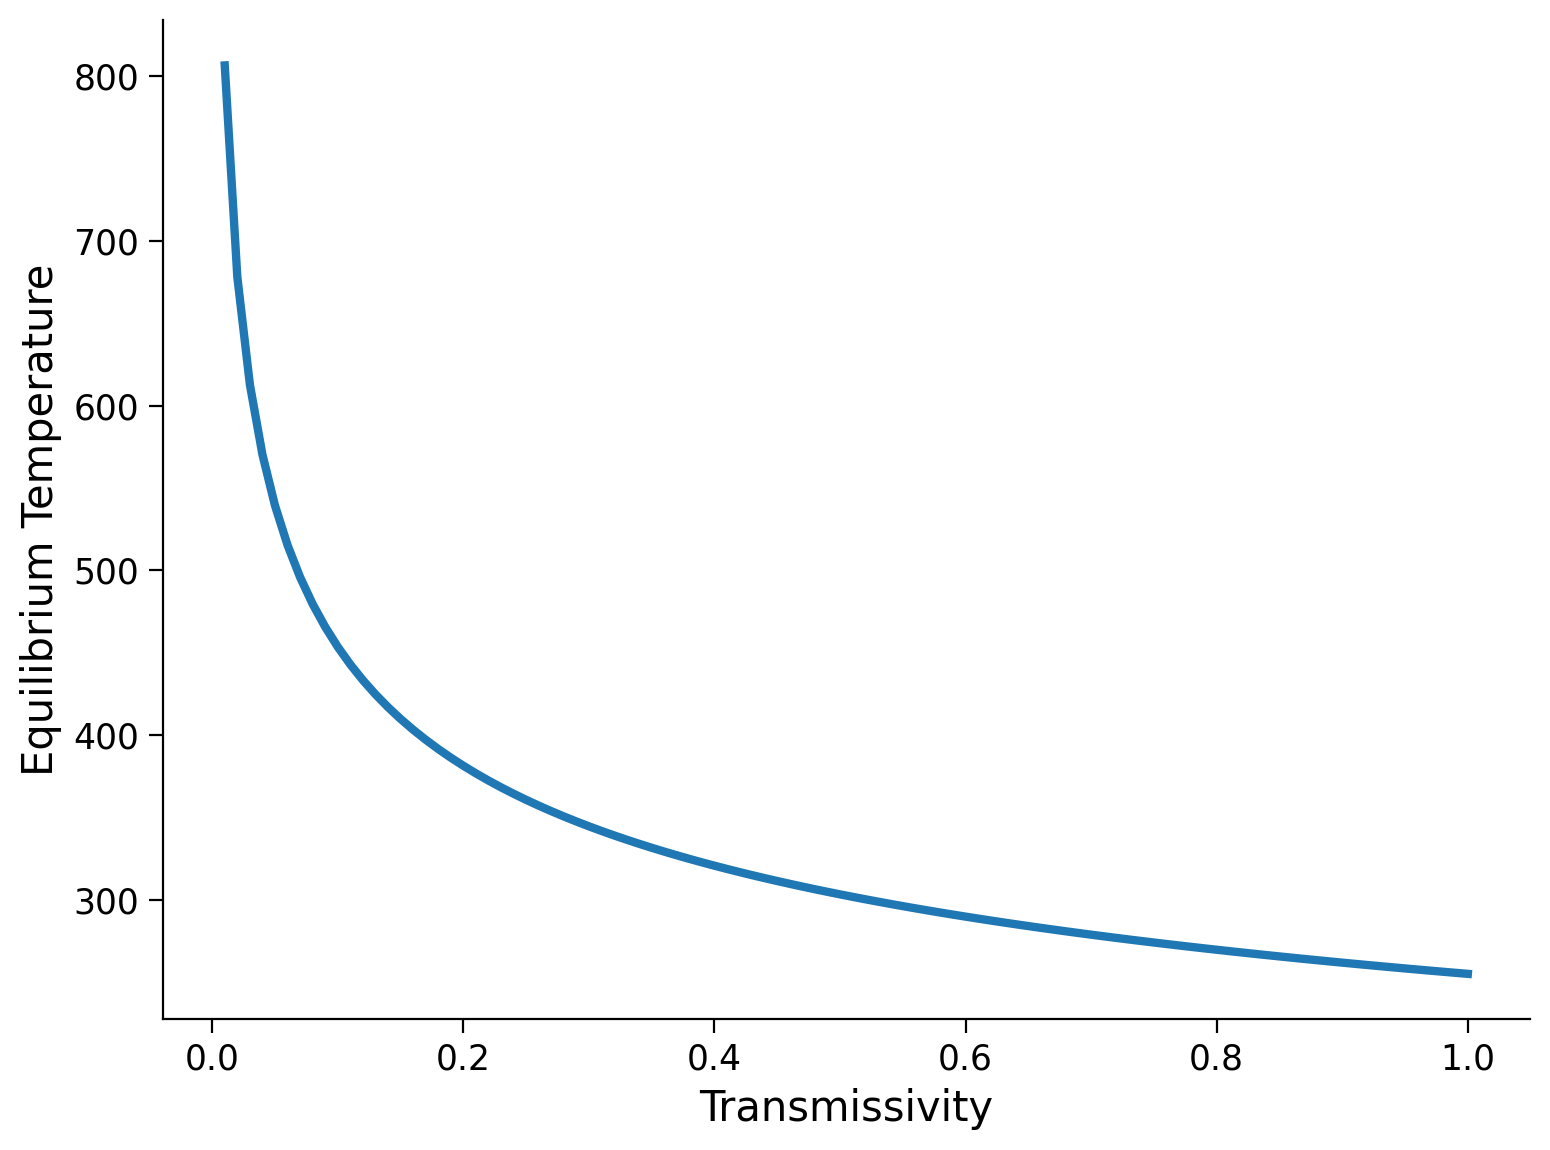

In [14]:

# define the observed insolation based on observations from the IPCC AR6 Figure 7.2
Q = 340  # W m^-2

# define the observed reflected radiation based on observations from the IPCC AR6 Figure 7.2
F_ref = 100  # W m^-2

# define albedo
alpha = F_ref / Q  # unitless number between 0 and 1

# define the Stefan-Boltzmann Constant, noting we are using 'e' for scientific notation
sigma = 5.67e-8  # W m^-2 K^-4


# define a function that returns the equilibrium temperature and takes argument tau
def get_eqT(tau):
    return (((1 - alpha) * Q) / (tau * sigma)) ** (1 / 4)


# define tau as an array extending from 0 to 1 with spacing interval 0.01
tau = np.arange(0, 1.01, 0.01)

# use list comprehension to obtain the equilibrium temperature as a function of tau
eqT = [get_eqT(t) for t in tau]

fig, ax = plt.subplots()
# Plot tau vs. eqT
_ = ax.plot(tau, eqT, lw=3)
ax.set_xlabel("Transmissivity")
ax.set_ylabel("Equilibrium Temperature")

[*Click for solution*](https://github.com/neuromatch/climate-course-content/tree/main/tutorials/W1D5_IntroductiontoClimateModeling/solutions/W1D5_Tutorial2_Solution_3fa7479c.py)

*Example output:*

<img alt='Solution hint' align='left' width=775.0 height=575.0 src=https://raw.githubusercontent.com/neuromatch/climate-course-content/main/tutorials/W1D5_IntroductiontoClimateModeling/static/W1D5_Tutorial2_Solution_3fa7479c_2.png>



In [15]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Coding_Exercises_3_1")

# Summary
In this tutorial, you explored the fundamentals of Earth's energy balance.  You learned how to calculate Earth's albedo $\mathbf{\alpha}$ and how absorbed shortwave radiation contributes to energy balance. You also discovered the concept of equilibrium temperature and it's relationship to energy balance. The tutorial also highlighted the impact of increasing greenhouse gases on the equilibrium temperature.

# Resources

Useful links:

- [Shortwave Radiation](https://glossarytest.ametsoc.net/wiki/Shortwave_radiation)
- [Insolation](https://glossary.ametsoc.org/wiki/Insolation)
- [Planetary Albedo](https://glossarytest.ametsoc.net/wiki/Planetary_albedo)
- The [Climate Laboratory](https://brian-rose.github.io/ClimateLaboratoryBook/) by Brian E. J. Rose